# Cortex Lamination

This notebook inspects the Cell2location mouse brain deconvolution workflow and Figure 5 layer logic. Smoke mode builds a small synthetic cortex-like gradient.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "repro").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate repository root; start Jupyter from the repository or notebooks directory.")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from repro.paths import get_runtime_config

CONFIG = get_runtime_config(data_dir="data", results_dir="results")
DATA_DIR = CONFIG.data_dir
RESULTS_DIR = CONFIG.results_dir
RUN_MODE = CONFIG.run_mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def path_label(path, env_name):
    raw = os.environ.get(env_name)
    if raw and Path(raw).is_absolute():
        return f"${env_name}"
    try:
        return str(Path(path).resolve().relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


config = pd.DataFrame([
    {"setting": "run_mode", "value": RUN_MODE},
    {"setting": "data_dir", "value": path_label(DATA_DIR, "FD_DATA_DIR")},
    {"setting": "results_dir", "value": path_label(RESULTS_DIR, "FD_RESULTS_DIR")},
])
display(config)


,setting,value
0,run_mode,smoke
1,data_dir,data
2,results_dir,results


## Build or Load Cortex Proportions

In [2]:

from repro.paths import missing_inputs_message
from repro.signatures import (
    create_reference_signatures,
    evaluate_with_markers,
    load_cortex_paired_data,
    run_cortex_flashdeconv,
    save_cortex_outputs,
)

if RUN_MODE == "full":
    mouse_root = DATA_DIR / "mouse_brain"
    required = [
        mouse_root / "scrna_reference.h5ad",
        mouse_root / "cell_annotation.csv",
        mouse_root / "C2L" / "ST" / "48" / "ST8059048_filtered_feature_bc_matrix.h5",
        mouse_root / "C2L" / "ST" / "48" / "spatial" / "tissue_positions_list.csv",
    ]
    message = missing_inputs_message(required, "follow README Cell2location Mouse Brain Dataset commands and place files under ./data/mouse_brain")
    if message:
        raise FileNotFoundError(message)
    sc_adata, sp_adata, common_genes = load_cortex_paired_data(DATA_DIR)
    X_ref, cell_types = create_reference_signatures(sc_adata)
    prop_df, elapsed = run_cortex_flashdeconv(sp_adata, X_ref, cell_types)
    results_df = evaluate_with_markers(sp_adata, prop_df, sc_adata)
    save_cortex_outputs(RESULTS_DIR, prop_df, sp_adata, cell_types, results_df)
    coords = sp_adata.obsm["spatial"]
    props = prop_df.values
else:
    side = 30
    x, y = np.meshgrid(np.arange(side), np.arange(side))
    coords = np.column_stack([y.ravel(), x.ravel()])
    depth = coords[:, 0] / max(coords[:, 0].max(), 1)
    cell_types = ["Ext_L23", "Ext_L25", "Ext_L56", "Ext_L6", "Ext_L6B", "Ext_Thal_1", "Ext_Hpc_CA1", "Ext_Hpc_DG2", "Oligo_2", "Micro"]
    layers = np.column_stack([
        np.exp(-((depth - 0.15) / 0.12) ** 2),
        np.exp(-((depth - 0.35) / 0.14) ** 2),
        np.exp(-((depth - 0.60) / 0.14) ** 2),
        np.exp(-((depth - 0.78) / 0.13) ** 2),
        np.exp(-((depth - 0.92) / 0.10) ** 2),
    ])
    context = np.column_stack([
        np.clip(1 - depth, 0, 1) * 0.15,
        np.clip(depth - 0.55, 0, 1) * 0.20,
        np.clip(depth - 0.70, 0, 1) * 0.18,
        np.full_like(depth, 0.05),
        np.full_like(depth, 0.03),
    ])
    props = np.column_stack([layers, context])
    props = props / (props.sum(axis=1, keepdims=True) + 1e-10)
    prop_df = pd.DataFrame(props, columns=cell_types)

summary = prop_df.mean().sort_values(ascending=False).head(8).reset_index()
summary.columns = ["cell_type", "mean_proportion"]
display(summary)


,cell_type,mean_proportion
0,Ext_L25,0.195657
1,Ext_L56,0.185976
2,Ext_L23,0.185523
3,Ext_L6,0.150096
4,Ext_L6B,0.117914
5,Ext_Thal_1,0.072004
6,Oligo_2,0.043450
7,Micro,0.026070


## Layer Profile Preview

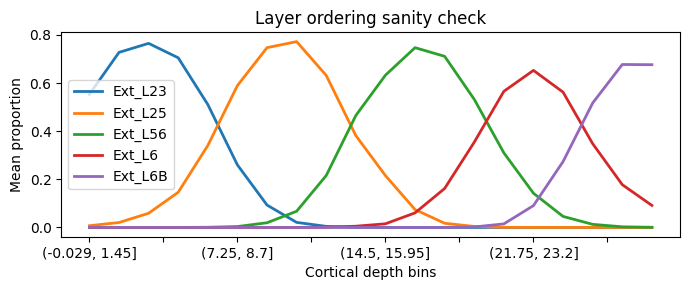

In [3]:

layer_cols = ["Ext_L23", "Ext_L25", "Ext_L56", "Ext_L6", "Ext_L6B"]
profile = prop_df[layer_cols].copy()
profile["depth"] = coords[:, 0]
profile = profile.groupby(pd.cut(profile["depth"], bins=20), observed=False)[layer_cols].mean()
ax = profile.plot(figsize=(7, 3), linewidth=2)
ax.set_xlabel("Cortical depth bins")
ax.set_ylabel("Mean proportion")
ax.set_title("Layer ordering sanity check")
plt.tight_layout()
plt.show()
